✅ Ready!
✅ Train | 38 classes | 43,444 images | /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train
✅ Val   | 38 classes | 10,861 images | /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val

📋 Classes (38):
  00. Apple___Apple_scab
  01. Apple___Black_rot
  02. Apple___Cedar_apple_rust
  03. Apple___healthy
  04. Blueberry___healthy
  05. Cherry_(including_sour)___Powdery_mildew
  06. Cherry_(including_sour)___healthy
  07. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  08. Corn_(maize)___Common_rust_
  09. Corn_(maize)___Northern_Leaf_Blight
  10. Corn_(maize)___healthy
  11. Grape___Black_rot
  12. Grape___Esca_(Black_Measles)
  13. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  14. Grape___healthy
  15. Orange___Haunglongbing_(Citrus_greening)
  16. Peach___Bacterial_spot
  17. Peach___healthy
  18. Pepper,_bell___Bacterial_spot
  19. Pepper,_bell___healthy
  20. Potato___Early_blight
  21. Potato___Late_blight
  22. Potato___healthy
  23. Rasp

100%|██████████| 74.5M/74.5M [00:00<00:00, 172MB/s]


✅ EfficientNet-B4 ready
   Trainable params : 14,043,742
   Frozen params    : 4,442,384
   Classifier head  : 1792 → 512 → 38
Epoch 01/15 | Loss: 1.3822 | Train: 80.12% | Val: 95.78%  💾 saved
Epoch 02/15 | Loss: 0.9369 | Train: 94.32% | Val: 97.68%  💾 saved
Epoch 03/15 | Loss: 0.8610 | Train: 96.34% | Val: 98.38%  💾 saved
Epoch 04/15 | Loss: 0.8256 | Train: 97.32% | Val: 98.67%  💾 saved
Epoch 05/15 | Loss: 0.8060 | Train: 97.74% | Val: 98.84%  💾 saved
Epoch 06/15 | Loss: 0.7929 | Train: 98.03% | Val: 98.99%  💾 saved
Epoch 07/15 | Loss: 0.7825 | Train: 98.37% | Val: 98.97%
Epoch 08/15 | Loss: 0.7752 | Train: 98.47% | Val: 99.06%  💾 saved
Epoch 09/15 | Loss: 0.7687 | Train: 98.59% | Val: 99.17%  💾 saved
Epoch 10/15 | Loss: 0.7631 | Train: 98.78% | Val: 99.19%  💾 saved
Epoch 11/15 | Loss: 0.7608 | Train: 98.78% | Val: 99.15%
Epoch 12/15 | Loss: 0.7588 | Train: 98.81% | Val: 99.17%
Epoch 13/15 | Loss: 0.7578 | Train: 98.84% | Val: 99.24%  💾 saved
Epoch 14/15 | Loss: 0.7550 | Train: 98.95%

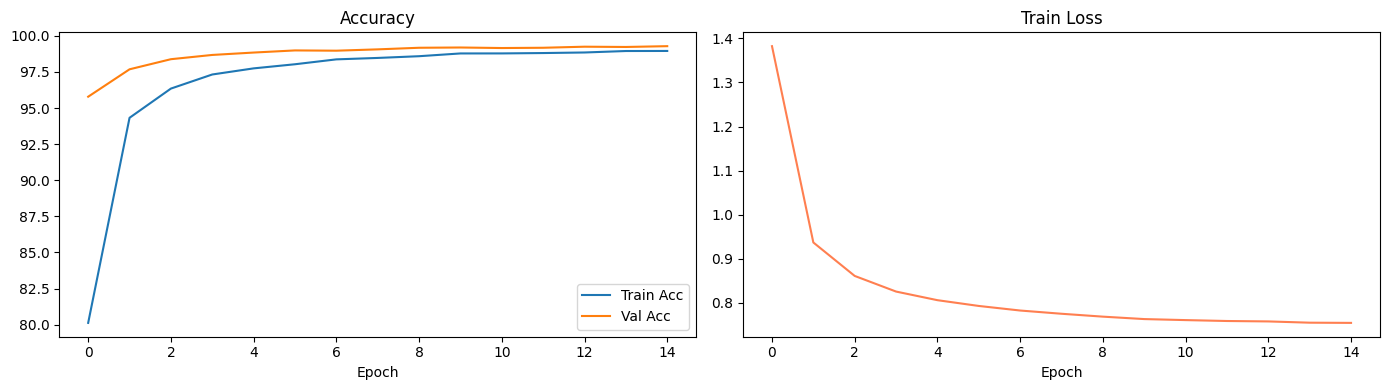


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98        63
                                 Apple___Black_rot       1.00      1.00      1.00        62
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        27
                                   Apple___healthy       0.99      0.99      0.99       165
                               Blueberry___healthy       0.99      1.00      0.99       150
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       105
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.94      0.92        51
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       120
               Corn_(maize)___Northern_Leaf_Blight     

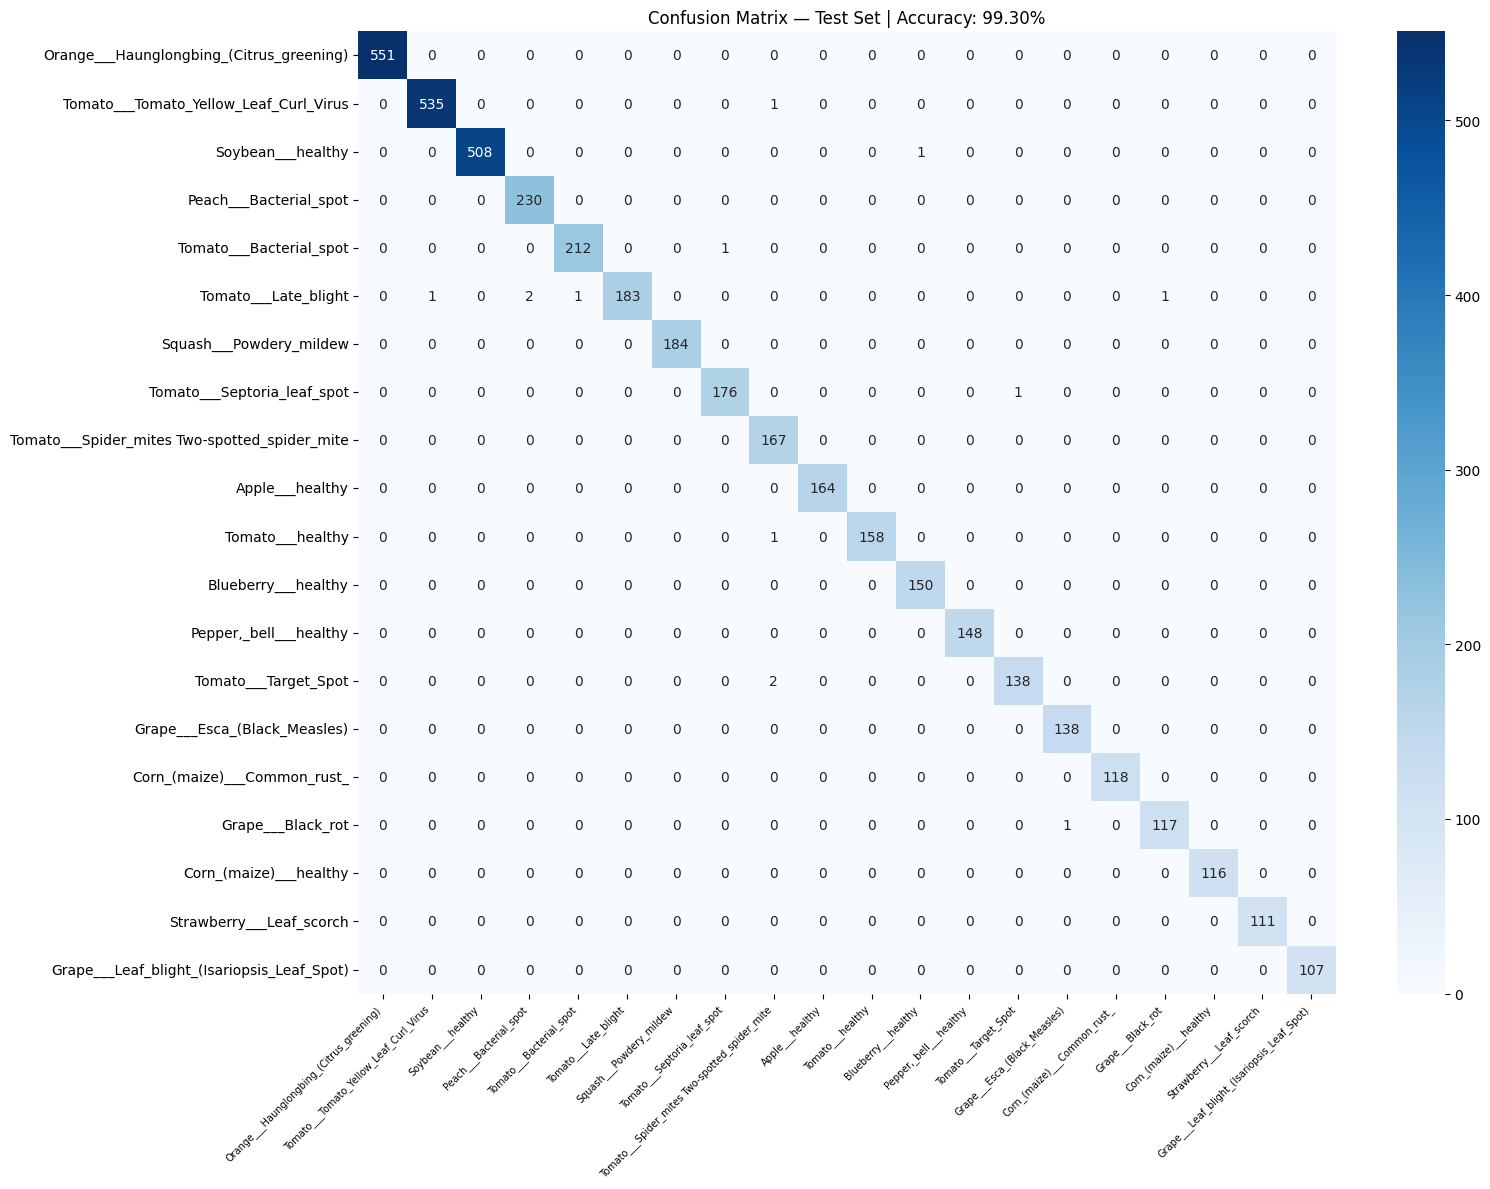

✅ Saved: best_model.pth | class_names.json | treatment_map.json
   Final Test Accuracy: 99.30%
✅ All outputs saved to /kaggle/working/

   Files saved:
   • __notebook__.ipynb                  0.03 MB
   • confusion_matrix.png                0.29 MB
   • treatment_map.json                  0.00 MB
   • best_model.pth                      71.24 MB
   • training_curves.png                 0.06 MB
   • class_names.json                    0.00 MB
   • metrics_summary.json                0.00 MB


In [1]:
#PART 1
!pip install -q gradio scikit-learn seaborn
print("✅ Ready!")
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 2
from pathlib import Path

TRAIN_DIR = Path("/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train")
VAL_DIR   = Path("/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val")

def count_images(folder):
    return sum(
        1 for ext in ["*.jpg","*.JPG","*.jpeg","*.JPEG","*.png","*.PNG"]
        for _ in Path(folder).glob(ext)
    )

for split_name, split_dir in [("Train", TRAIN_DIR), ("Val", VAL_DIR)]:
    if split_dir.exists():
        classes_found = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        total         = sum(count_images(split_dir/c) for c in classes_found)
        print(f"✅ {split_name:5s} | {len(classes_found)} classes | {total:,} images | {split_dir}")
    else:
        print(f"❌ {split_name} directory NOT found at {split_dir}")

classes      = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
print(f"\n📋 Classes ({len(classes)}):")
for i, c in enumerate(classes):
    print(f"  {i:02d}. {c}")

#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 3
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split

def get_images(folder):
    imgs = []
    for ext in ["*.jpg","*.JPG","*.jpeg","*.JPEG","*.png","*.PNG"]:
        imgs.extend(Path(folder).glob(ext))
    return imgs

def build_lists(split_dir):
    images, labels = [], []
    for cls in classes:
        cls_dir = Path(split_dir) / cls
        if not cls_dir.exists():
            continue
        for img_path in get_images(cls_dir):
            images.append(str(img_path))
            labels.append(class_to_idx[cls])
    return images, labels

train_imgs, train_lbls = build_lists(TRAIN_DIR)
all_val_imgs, all_val_lbls = build_lists(VAL_DIR)

val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    all_val_imgs, all_val_lbls,
    test_size=0.5,
    stratify=all_val_lbls,
    random_state=42
)

print(f"Train : {len(train_imgs):,} images")
print(f"Val   : {len(val_imgs):,} images")
print(f"Test  : {len(test_imgs):,} images")
print(f"Classes: {len(classes)}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((400, 400)),
    transforms.RandomCrop((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PlantDiseaseDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = PlantDiseaseDataset(train_imgs, train_lbls, train_transform)
val_dataset   = PlantDiseaseDataset(val_imgs,   val_lbls,   eval_transform)
test_dataset  = PlantDiseaseDataset(test_imgs,  test_lbls,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 4
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)

# Freeze all layers first
for p in backbone.parameters():
    p.requires_grad = False

# Unfreeze last 2 blocks for domain adaptation
for p in backbone.features[6].parameters():
    p.requires_grad = True
for p in backbone.features[7].parameters():
    p.requires_grad = True

# Replace classifier head
in_features = backbone.classifier[1].in_features
backbone.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.GELU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, len(classes))
)

model = backbone.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters()) - trainable
print(f"✅ EfficientNet-B4 ready")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {frozen:,}")
print(f"   Classifier head  : {in_features} → 512 → {len(classes)}")

#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 5
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 15
LR     = 3e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {"params": model.features[6].parameters(), "lr": LR * 0.1},
    {"params": model.features[7].parameters(), "lr": LR * 0.1},
    {"params": model.classifier.parameters(),  "lr": LR},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc     = 0.0
patience_counter = 0
history          = {"train_acc": [], "val_acc": [], "train_loss": []}

for epoch in range(EPOCHS):
    model.train()
    t_loss = t_correct = t_total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += (logits.argmax(1) == labels).sum().item()
        t_total   += imgs.size(0)
    scheduler.step()

    model.eval()
    v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits       = model(imgs)
            v_correct   += (logits.argmax(1) == labels).sum().item()
            v_total     += imgs.size(0)

    t_acc      = t_correct / t_total * 100
    v_acc      = v_correct / v_total * 100
    t_loss_avg = t_loss    / t_total

    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["train_loss"].append(t_loss_avg)

    saved = ""
    if v_acc > best_val_acc:
        best_val_acc     = v_acc
        patience_counter = 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        saved = "  💾 saved"
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {t_loss_avg:.4f} | "
          f"Train: {t_acc:.2f}% | "
          f"Val: {v_acc:.2f}%{saved}")

    if patience_counter >= 4:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training complete! Best Val Acc: {best_val_acc:.2f}%")

#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 6
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits       = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(labels.cpu().numpy())

test_acc = sum(p==t for p,t in zip(all_preds, all_true)) / len(all_true) * 100
print(f"✅ Test Accuracy: {test_acc:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_acc"], label="Train Acc")
axes[0].plot(history["val_acc"],   label="Val Acc")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(history["train_loss"], color="coral")
axes[1].set_title("Train Loss"); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=classes, zero_division=0))

top_idx   = [i for i, _ in Counter(all_true).most_common(20)]
top_names = [classes[i] for i in top_idx]
mask_idx  = [i for i, t in enumerate(all_true) if t in top_idx]
cm        = confusion_matrix([all_true[i] for i in mask_idx],
                             [all_preds[i] for i in mask_idx], labels=top_idx)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=top_names, yticklabels=top_names, cmap="Blues")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.title(f"Confusion Matrix — Test Set | Accuracy: {test_acc:.2f}%")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------
#PART 7
import json

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(classes, f)

TREATMENTS = {
    "healthy"              : "✅ Healthy! Maintain regular watering and balanced fertilisation.",
    "bacterial_spot"       : "🔬 Apply copper-based bactericide. Remove infected leaves. Avoid overhead watering.",
    "early_blight"         : "🍂 Apply chlorothalonil or mancozeb fungicide. Rotate crops annually.",
    "late_blight"          : "⚠️ Apply metalaxyl immediately. Remove and destroy infected plants.",
    "leaf_mold"            : "🍃 Improve airflow. Apply chlorothalonil fungicide.",
    "septoria_leaf_spot"   : "🌿 Remove lower leaves. Apply copper fungicide.",
    "spider_mites"         : "🕷️ Spray neem oil or insecticidal soap. Increase humidity.",
    "target_spot"          : "🎯 Apply azoxystrobin fungicide. Avoid wetting leaves.",
    "mosaic_virus"         : "🦠 No cure — remove infected plants. Control aphid vectors.",
    "yellow_leaf_curl"     : "🌀 Control whiteflies with imidacloprid. Use resistant varieties.",
    "powdery_mildew"       : "⬜ Apply sulfur or potassium bicarbonate spray.",
    "black_rot"            : "⚫ Prune infected wood. Apply copper-based fungicide.",
    "cercospora_leaf_spot" : "🟤 Apply copper fungicide. Improve drainage.",
    "common_rust"          : "🟠 Apply triazole fungicide. Plant resistant hybrids.",
    "northern_leaf_blight" : "💨 Apply strobilurin fungicide. Rotate crops.",
    "apple_scab"           : "🍎 Apply fungicide at bud break. Remove fallen leaf litter.",
    "cedar_apple_rust"     : "🍎 Apply myclobutanil. Remove nearby cedar trees.",
    "esca"                 : "🍷 Remove infected vines. No chemical cure — prevention is key.",
    "haunglongbing"        : "🍋 No cure. Remove infected trees. Control psyllid vectors.",
    "grape_leaf_blight"    : "🍇 Apply mancozeb fungicide. Ensure good canopy airflow.",
    "squash_powdery_mildew": "🎃 Apply potassium bicarbonate. Plant resistant varieties.",
}

def get_treatment(cls_name):
    name = cls_name.lower()
    if "healthy" in name:
        return TREATMENTS["healthy"]
    for key, val in TREATMENTS.items():
        if key in name:
            return val
    return "⚠️ Consult your local agricultural extension officer."

treatment_map = {c: get_treatment(c) for c in classes}
with open("/kaggle/working/treatment_map.json", "w") as f:
    json.dump(treatment_map, f, indent=2)

print("✅ Saved: best_model.pth | class_names.json | treatment_map.json")
print(f"   Final Test Accuracy: {test_acc:.2f}%")

#-----------------------------------------------------------------------------------



import os, json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

metrics = {
    "model"             : "EfficientNet-B4",
    "timestamp"         : timestamp,
    "best_val_acc"      : round(best_val_acc, 4),
    "test_acc"          : round(test_acc, 4),
    "epochs_trained"    : len(history["train_acc"]),
    "train_acc_history" : [round(x, 4) for x in history["train_acc"]],
    "val_acc_history"   : [round(x, 4) for x in history["val_acc"]],
    "train_loss_history": [round(x, 4) for x in history["train_loss"]],
    "num_classes"       : len(classes),
    "train_images"      : len(train_imgs),
    "val_images"        : len(val_imgs),
    "test_images"       : len(test_imgs),
}
with open("/kaggle/working/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"✅ All outputs saved to /kaggle/working/")
print(f"\n   Files saved:")
for f in os.listdir("/kaggle/working/"):
    size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
    print(f"   • {f:35s} {size:.2f} MB")